In [9]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import trim_mean
from sklearn.preprocessing import StandardScaler
import statistics as st
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats import weightstats
import statistics
import random
import warnings
warnings.filterwarnings('ignore')

 Part A

#The following data represents the price in dollars for branded shirts in a website NuCloth.

23 30 20 27 44 26 35 20 29 29

25 15 18 27 19 22 12 26 34 15

27 35 26 43 35 14 24 12 23 31

40 35 38 57 22 42 24 21 27 33

#Use this data for answering following questions where relevant

 # Q1. Compute the mean, median and the mode of the data

In [82]:
data=np.array([23,30,20,27,44,26,35,20,29,29,
               25,15,18,27,19,22,12,26,34,15,
               27,35,26,43,35,14,24,12,23,31,
               40,35,38,57,22,42,24,21,27,33])
print('Mean of the Price is :', np.mean(data))
print('Median of the Price is :', np.median(data))
print('Mode of the Price is :', st.mode(data))

Mean of the Price is : 27.625
Median of the Price is : 26.5
Mode of the Price is : 27


Q2. Compute the range , variance and standard deviation of the data

In [83]:
print('Range of the Price is :', max(data)-min(data))
print('variance of the Price is :', np.var(data))
print('Standard Deviation of the Price is :', np.std(data))

Range of the Price is : 45
variance of the Price is : 90.284375
Standard Deviation of the Price is : 9.501809038283184


Q3. Find the mean deviation for the data . The mean deviation is defined as below.

In [84]:
x_bar = np.mean(data)
x_bar
for x in data:
    mu=x-x_bar/len(data)
print('Mean Deviation of Price is : ',mu)

Mean Deviation of Price is :  32.309375


Q4. Calculate the Pearson coefficient of skewness and comment on the skewness of the data [A measure to determine the skewness of a distribution is called the Pearson coefficient of skewness. Formula = 3*(mean-median)/sd

In [85]:
mean = np.mean(data)
median = np.median(data)
sd= np.std(data) 
print('Pearson coefficient of skewness of Price is ',3*((mean-median)/sd))
# the distribution is positively skewed and moderately skewed since it lies between 0.5 and 1.

Pearson coefficient of skewness of Price is  0.35519551975860436


Coefficient of skewness is 0.3 Hence, Data is symmetrically distributed

# Q5. Count the number of data values that fall within two standard deviations of the mean. Compare this with the answer from Chebyshev’s Theorem

In [89]:
from scipy.stats import zscore
z_score=zscore(data)
z_score
len(z_score[(z_score>-2)&(z_score<2)])

39

39 values fall with in two standard deviations of the mean 

Q6. Find the three quartiles and the interquartile range (IQR).

In [94]:
print ('first Quartile range is :',np.quantile(data,0.25))
print ('second Quartile range is :',np.quantile(data,0.50))
print ('Third Quartle range is:', np.quantile(data,0.75))

first Quartile range is : 21.75
second Quartile range is : 26.5
Third Quartle range is: 34.25


In [96]:
Q1=np.quantile(data,0.25)
Q3=np.quantile(data,0.75)
print('IQR is :',Q3-Q1)

IQR is : 12.5


Q7. Are there any outliers in the data set ?

In [97]:
z_score[(z_score>3)|(z_score<-3)]

array([3.09151656])

In [98]:
len(z_score[(z_score>3)|(z_score<-3)])

1

Yes there is one outlier in data

Q8. Draw a boxplot of the dataset to confirm.

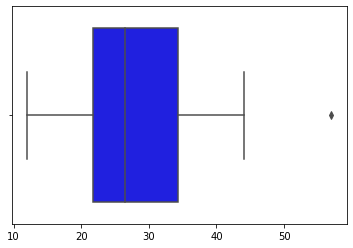

In [100]:
sns.boxplot(data,color='Blue')
plt.show()

Boxplot confirm there is one outlier

Q9. Find the percentile rank of the datapoint 25.

In [102]:
dataframe=pd.DataFrame(data)
pr=stats.percentileofscore(a=data,score=25,kind='rank')
print('The percentile rank of the datapoint 25 is',pr)

The percentile rank of the datapoint 25 is 42.5


Q10. What is the probability that a shirt cost is above 25 dollars?

In [108]:
stats.norm.sf(25.0,mean,sd)

0.608827033824017

Probabillity of shirt cost above 25 dollar is  0.608827033824017

Q11. Create a frequency distribution for the data and visualize it appropriately

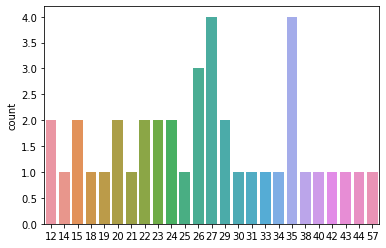

In [115]:
sns.countplot(data)
plt.show()

Q12. Create a probability distribution of the data and visualize it appropriately.

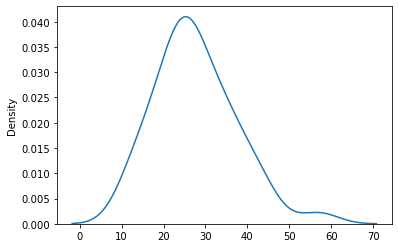

In [119]:
sns.kdeplot(data)
plt.show()

Q13. What is the shape of the distribution of this dataset? Create an appropriate graph to determine that. Take 100 random samples with replacement from this dataset of size 5 each. Create a sampling distribution of the mean shirt prices. Compare with other sampling distributions of sample size 10, 15, 20, 25, 30. State your observations. Does it corroborate the Central Limit Theorem?

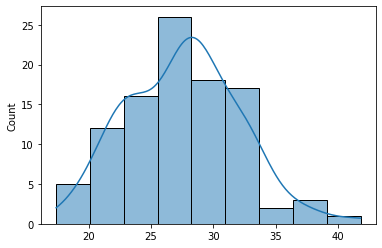

In [130]:
# Sample distribution of sample size 5
l1 =[]
for i in range(1,101):
    sample1=random.choices(data,k=5)
    l1.append(np.mean(sample1))
sns.histplot(l1,kde=True)
plt.show()

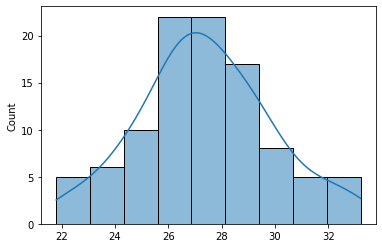

In [133]:
# Sampling distribution of sample size 10
l2 =[]
for i in range(1,101):
    sample2=random.choices(data,k=10)
    l2.append(np.mean(sample2))
sns.histplot(l2,kde=True)
plt.show()

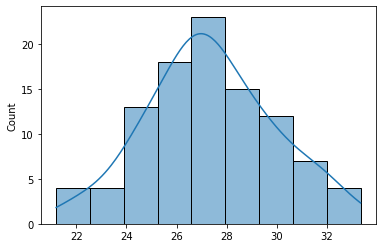

In [136]:
# Sampling distribution of sample size 15
l3 =[]
for i in range(1,101):
    sample3=random.choices(data,k=15)
    l3.append(np.mean(sample3))
sns.histplot(l3,kde=True)
plt.show()

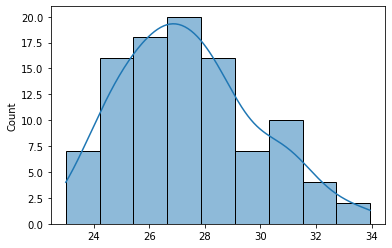

In [137]:
# Sampling distribution of sample size 20
l4 =[]
for i in range(1,101):
    sample4=random.choices(data,k=20)
    l4.append(np.mean(sample4))
sns.histplot(l4,kde=True)
plt.show()

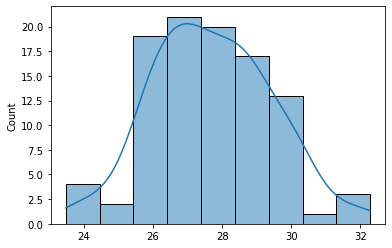

In [139]:
# Sampling distribution of sample size 25
l5 =[]
for i in range(1,101):
    sample5=random.choices(data,k=25)
    l5.append(np.mean(sample5))
sns.histplot(l5,kde=True)
plt.show()

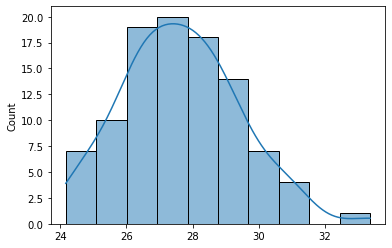

In [140]:
# Sampling distribution of sample size 30
l6 =[]
for i in range(1,101):
    sample6=random.choices(data,k=30)
    l6.append(np.mean(sample6))
sns.histplot(l6,kde=True)
plt.show()

The sampling distribution of mean is always normally distributed. Therefore it follows the central Limit Theroem 

Q14. Treat this dataset as a binomial distribution where p is the probability that a shirt costs above 25 dollars. What is the probability that out of a random sample of 10 shirts 7 are costing more than 25 dollars?

In [143]:
n = 10
x = 7
total=len(data)
observed=len(data[data>=25])
p=observed/total
print('probability that out of a random sample of 10 shairts 7 are costing more than 25 dollars is',stats.binom.pmf(x,n,p))

probability that out of a random sample of 10 shairts 7 are costing more than 25 dollars is 0.21499084799999976


Q15. NuCloth Claims that 60% of all shirts in their website cost less than 25 dollars . Using the Normal approximation of a Binomial distribution, find the probability that in a random sample of 10 shirts 7 of them will cost less than 25 dollars. [ Note that the normal distribution can be used to approximate a binomial distribution if np>=5 and nq>=5 with the following correction for continuity P(X=z) = P(z-0.5 < X < z+0.5 ) ]

In [146]:
p = 0.6
n=10
x=7
print('probability that in a random sample of 10 shirts 7 of them will cost less than 25 dollars is',stats.binom.pmf(x,n,p))

probability that in a random sample of 10 shirts 7 of them will cost less than 25 dollars is 0.21499084799999976


Q16. Compute a 95% Confidence Interval for the true price of a shirt in the NuCloth website using appropriate distribution. (State reasons as to why did you use a z or t distribution)

In [147]:
# Here t distribution will be used because the population standard deviation is not known

In [151]:
std=np.std(data,ddof=1)
std
n=len(data)
n
mean

27.625

In [153]:
stats.t.interval(0.95,loc=mean,scale=(std/n**0.5),df=n-1)

(24.547461337585172, 30.702538662414828)

Q17. A data scientist wants to estimate with 95% confidence the true proportion of shirts having price greater than 25 dollars in the NuCloth website. A recent study showed that 60% of all shirts have a price greater than 25 dollars. The data scientist wants to be accurate within 2% of the true proportion. Find the minimum sample size necessary.

In [157]:
p_pop=0.6
q_pop=1-0.6
alpha=0.05
z_alpha_by_2=stats.norm.sf(alpha/2)
E=0.02
# E is the margin of error
n =(p_pop*q_pop) * ((z_alpha_by_2)/(E))**2
output=np.ceil(n)
print ('Minimum sample size required for this analysis is:',output)

Minimum sample size required for this analysis is: 145.0


Q18. The same data scientist wants to estimate the true proportion of shirts having price greater than 25 dollars. She wants to be 90% confident and accurate within 5% of true proportion. Find the minimum sample size necessary.

In [160]:
total = len(data)
observed=len(data[data>=25])
p_pop=1-p_pop
alpha=0.1
E=0.05
z_alpha_by_2=stats.norm.sf(alpha/2)
n=(p_pop*q_pop)*((z_alpha_by_2)/(E))**2
output=np.ceil(n)
print('Minimum sample size required for this analysis is:',output)

Minimum sample size required for this analysis is: 15.0


Q19. NuCloth claims that currently 80% of all shirts have prices greater than 25 dollars . Test this claim with an alpha =0.05 if out of a random sample of 30 shirts only 23 are having prices above 25 dollars.

In [161]:
H0 :p<=0.8
H1 :p>0.8

In [165]:
alpha=0.05
n=30
x=23
p_samp=x/n
hypo_p=0.8

In [166]:
z_stat=(p_samp-hypo_p)/np.sqrt((hypo_p*(1-hypo_p))/n)
z_stat

-0.45643546458763834

In [167]:
p_value=stats.norm.sf(z_stat)
p_value

0.6759615659304269

since pvalue is greater than 0.05 we fail to reject HO.Therefore  There is no enough evidence to say that 80% of all shirts have 
price greater than 25 dollars.

Q20. A data scientist is researching the hypothesis that the average price of a shirt in NuCloth is higher than the supermarket. So he collects data from NuCloth and the supermarket that the average shirt price of shirts in NuCloth is 36 dollars vs 34 dollars in the supermarket. The standard deviations are 7.6 and 5.8 respectively.Suppose the data scientist got these values after randomly selecting 100 shirts from each place. a. What hypothesis would he use to compare the shirt prices of NuCloth vsSupermarket b. What are critical values to be used? c. What statistical test will be used to compare these prices? d. Complete the test and obtain the P-value. e. Summarize his conclusion based on the P-value.

A. What hypothesis would he use to compare the shirt prices of NuCloth vsSupermarket

In [ ]:
H0 : ul<=u2
Hl : ul>u2
u1: Average shirt price of NuCloth
u1: Average shirt price of supermarket

In [192]:
x1_bar=36
x2_bar=34
s1= 7.6
s2 = 5.8
n1 = 100
n2 = 100
null_value=0
#degree of freedom for 2 sample t-test
print('Degrees of freedom:', n1+n2-2)

Degrees of freedom: 198


B. What are critical values to be used?

In [193]:
alpha= 0.05
z_critical=stats.norm.isf(alpha)
print('critical values to be used is ',z_critical)

critical values to be used is  1.6448536269514729


C. What statistical test will be used to compare these prices?

Two Sample T-test will be used to compare the means of these prices

D.Complete the test and obtain the P-value.

In [195]:
# Calculate the pooled Standard deviation
s = np.sqrt((((n1-1)*s1**2)+((n2-1)*s2**2))/(n1 + n2 - 2))
t_stat = (x1_bar - x2_bar) / (s * np.sqrt(n1 + 1/n2))
p_value=stats.t.sf(t_stat,df = n1 + n2 - 2)
print('Test Statistics:', t_stat,'p_value',p_value)

Test Statistics: 0.029583542796215133 p_value 0.48821449397213373


E. Summarize his conclusion based on the P-value.

Since pvalue is less than 0.05  we reject HO. Therefore average shirt price of Nucloth is greater than average shirt price of supermarket

Part B

In [11]:
df = pd.read_json('modcloth_final_data.json',lines= True)
df.head()


,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,5ft 6in,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,5ft 7in,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN
3,123373,NaN,21,5.0,dd/e,NaN,NaN,new,NaN,NaN,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,NaN
4,123373,NaN,18,5.0,b,NaN,36.0,new,NaN,5ft 2in,dberrones1,slightly long,small,944840,NaN,NaN,NaN,NaN


In [12]:
df.head()

,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,5ft 6in,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,5ft 7in,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN
3,123373,NaN,21,5.0,dd/e,NaN,NaN,new,NaN,NaN,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,NaN
4,123373,NaN,18,5.0,b,NaN,36.0,new,NaN,5ft 2in,dberrones1,slightly long,small,944840,NaN,NaN,NaN,NaN


Check the datashape 

In [206]:
df.shape

(82790, 18)

In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82790 entries, 0 to 82789
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   item_id         82790 non-null  int64  
 1   waist           2882 non-null   float64
 2   size            82790 non-null  int64  
 3   quality         82722 non-null  float64
 4   cup size        76535 non-null  object 
 5   hips            56064 non-null  float64
 6   bra size        76772 non-null  float64
 7   category        82790 non-null  object 
 8   bust            11854 non-null  object 
 9   height          81683 non-null  object 
 10  user_name       82790 non-null  object 
 11  length          82755 non-null  object 
 12  fit             82790 non-null  object 
 13  user_id         82790 non-null  int64  
 14  shoe size       27915 non-null  float64
 15  shoe width      18607 non-null  object 
 16  review_summary  76065 non-null  object 
 17  review_text     76065 non-null 

In [209]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
item_id,82790.0,469325.229170,213999.803314,123373.0,314980.00,454030.0,658440.00,807722.0
waist,2882.0,31.319223,5.302849,20.0,28.00,30.0,34.00,50.0
size,82790.0,12.661602,8.271952,0.0,8.00,12.0,15.00,38.0
quality,82722.0,3.949058,0.992783,1.0,3.00,4.0,5.00,5.0
hips,56064.0,40.358501,5.827166,30.0,36.00,39.0,43.00,60.0
bra size,76772.0,35.972125,3.224907,28.0,34.00,36.0,38.00,48.0
user_id,82790.0,498849.564718,286356.969459,6.0,252897.75,497913.5,744745.25,999972.0
shoe size,27915.0,8.145818,1.336109,5.0,7.00,8.0,9.00,38.0


Check the null value of dataset

In [212]:
df.isnull().sum()


item_id               0
waist             79908
size                  0
quality              68
cup size           6255
hips              26726
bra size           6018
category              0
bust              70936
height             1107
user_name             0
length               35
fit                   0
user_id               0
shoe size         54875
shoe width        64183
review_summary     6725
review_text        6725
dtype: int64

In [217]:
df.columns

Index(['item_id', 'waist', 'size', 'quality', 'cup size', 'hips', 'bra size',
       'category', 'bust', 'height', 'user_name', 'length', 'fit', 'user_id',
       'shoe size', 'shoe width', 'review_summary', 'review_text'],
      dtype='object')

Correlation of the dataset

In [226]:
df.corr()

,item_id,waist,size,quality,hips,bra size,user_id,shoe size
item_id,1.000000,0.023007,0.004712,0.011850,0.006440,-0.005902,0.007144,0.021842
waist,0.023007,1.000000,0.846494,0.015710,0.832980,0.761668,-0.011112,0.315472
size,0.004712,0.846494,1.000000,-0.024556,0.747257,0.788460,-0.005214,0.447805
quality,0.011850,0.015710,-0.024556,1.000000,-0.017317,-0.019930,0.004547,-0.025066
hips,0.006440,0.832980,0.747257,-0.017317,1.000000,0.671034,-0.006886,0.417403
bra size,-0.005902,0.761668,0.788460,-0.019930,0.671034,1.000000,-0.000769,0.415777
user_id,0.007144,-0.011112,-0.005214,0.004547,-0.006886,-0.000769,1.000000,0.005364
shoe size,0.021842,0.315472,0.447805,-0.025066,0.417403,0.415777,0.005364,1.000000


Check the mean and median

In [227]:
df.mean()

item_id      469325.229170
waist            31.319223
size             12.661602
quality           3.949058
hips             40.358501
bra size         35.972125
user_id      498849.564718
shoe size         8.145818
dtype: float64

In [228]:
df.median()

item_id      454030.0
waist            30.0
size             12.0
quality           4.0
hips             39.0
bra size         36.0
user_id      497913.5
shoe size         8.0
dtype: float64

Check the datatype of dataset

In [234]:
df.dtypes

item_id             int64
waist             float64
size                int64
quality           float64
cup size           object
hips              float64
bra size          float64
category           object
bust               object
height             object
user_name          object
length             object
fit                object
user_id             int64
shoe size         float64
shoe width         object
review_summary     object
review_text        object
dtype: object

4.3 Check the distribution of the variables using Histogram or Dist plot or KDE and boxplot etc. Kindly explore at least two.

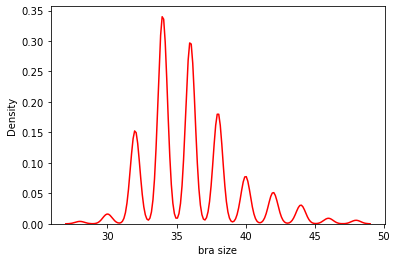

In [13]:
sns.kdeplot(df['bra size'],color='red')
plt.show()

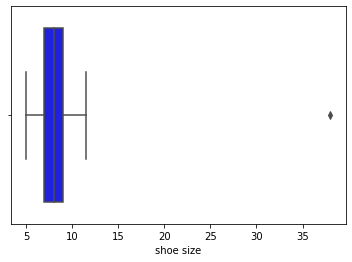

In [18]:
sns.boxplot(df['shoe size'],color='Blue')
plt.show()

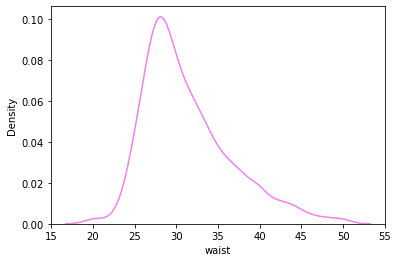

In [29]:
sns.kdeplot(df['waist'],color='violet')
plt.show()

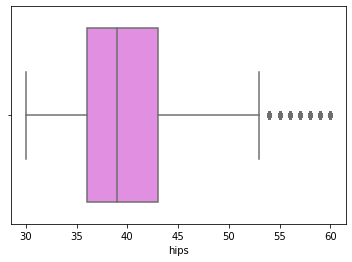

In [32]:
sns.boxplot(df['hips'],color='violet')
plt.show()

4.4 Check the Skewness and Kurtosis. Explain what the Skewness and Kurtosis describe.

In [33]:
df.skew()

item_id     -0.120644
waist        0.993061
size         1.128301
quality     -0.676777
hips         0.969187
bra size     0.901004
user_id      0.008201
shoe size    0.436713
dtype: float64

In [34]:
df.kurt()

item_id     -1.215909
waist        0.836624
size         0.760010
quality     -0.167085
hips         0.848464
bra size     1.039445
user_id     -1.182436
shoe size    8.448820
dtype: float64

Skewness is a measure of symmetry, or more precisely, the lack of symmetry.kurtosis is a measure of whether the data are heavy-tailed
relative to a normaldistribution.

if the skewness is less than-1 or greter than 1, trhe data are highly skewed.

For example:Height Column
    
if the kurtosis number is greater than +1, the distribution is too peaked.

For example:Height Column
    

4.5 Based on the above approach impute the missing values with the right metric. Or If you want to get some analysis before imputing missing values feel free to explore the analysis




df=df1

In [45]:
df.isnull().sum()/len(df)*100

item_id            0.000000
size               0.000000
quality            0.082136
cup size           7.555260
hips               0.000000
bra size           7.268994
category           0.000000
height             1.337118
user_name          0.000000
length             0.042276
fit                0.000000
user_id            0.000000
shoe size         66.282160
shoe width        77.525063
review_summary     8.122962
review_text        8.122962
dtype: float64

In [39]:
df=df.drop(['waist','bust'],axis=1)

In [42]:
# Since the hips column was not symmetric we replaced the null values by the median of the column
df['hips'].fillna(df['hips'].median(),inplace=True)

In [46]:
df=df
df.isnull().sum()/len(df)*100

item_id            0.000000
size               0.000000
quality            0.082136
cup size           7.555260
hips               0.000000
bra size           7.268994
category           0.000000
height             1.337118
user_name          0.000000
length             0.042276
fit                0.000000
user_id            0.000000
shoe size         66.282160
shoe width        77.525063
review_summary     8.122962
review_text        8.122962
dtype: float64

In [58]:
df.dropna(subset='quality',inplace=True)
df.dropna(subset=(['cup size','bra size']),inplace=True)
df.dropna(subset=(['height','length','review_summary']),inplace=True)
df.dropna(subset=(['user_id','shoe width']),inplace=True)

In [59]:
df.isnull().sum()/len(df)*100

item_id           0.000000
size              0.000000
quality           0.000000
cup size          0.000000
hips              0.000000
bra size          0.000000
category          0.000000
height            0.000000
user_name         0.000000
length            0.000000
fit               0.000000
user_id           0.000000
shoe size         3.696824
shoe width        0.000000
review_summary    0.000000
review_text       0.000000
dtype: float64

In [63]:
df['shoe width'].value_counts()

average    11798
wide        3496
narrow      1396
Name: shoe width, dtype: int64

In [68]:
df['shoe size'].fillna(df['shoe size'].mean(),inplace=True)
df['shoe width'].fillna('average',inplace=True)

In [69]:
df.isnull().sum()/len(df)*100

item_id           0.0
size              0.0
quality           0.0
cup size          0.0
hips              0.0
bra size          0.0
category          0.0
height            0.0
user_name         0.0
length            0.0
fit               0.0
user_id           0.0
shoe size         0.0
shoe width        0.0
review_summary    0.0
review_text       0.0
dtype: float64

The missing value have been imputed

 5 Find the outliers which are below and above 2.5 * IQR - Q1 and 2.5 * IQR + Q3.

In [20]:
Q1 = df.quantile(0.25)
Q2 = df.quantile(0.5)
Q3 = df.quantile(0.75)
IQR=Q3-Q1
IQR

item_id      343460.0
waist             6.0
size              7.0
quality           2.0
hips              7.0
bra size          4.0
user_id      491847.5
shoe size         2.0
dtype: float64

In [23]:
LL = (2.5*IQR-Q1)
UL = (2.5*IQR+Q3)


In [24]:
df_new = df[~((df<LL)|(df>UL)).any(axis=1)]

In [25]:
df_new

,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
52246,545232,NaN,12,4.0,dddd/g,46.0,36.0,tops,47,5ft 7in,Renee,slightly short,fit,989953,8.5,average,I really love this shirt.,I really love this shirt. I just wish it was s...
52273,545871,NaN,15,4.0,ddd/f,NaN,36.0,tops,NaN,5ft 6in,Linds,just right,small,986260,NaN,NaN,So cute but shrunk,"I loved this shirt. It fit almost perfectly, ..."
52282,546664,39.0,12,3.0,dd/e,45.0,36.0,tops,NaN,5ft 2in,Richelle,slightly long,large,984733,NaN,NaN,Might be a bit on the loo,Might be a bit on the loose side I found it di...
52297,546664,NaN,12,4.0,dddd/g,45.0,40.0,tops,NaN,5ft 2in,kimkurkinen,just right,small,985796,NaN,NaN,"Usually wear a 1x, but ba","Usually wear a 1x, but based on reviews bought..."
52357,546664,NaN,12,5.0,d,44.0,36.0,tops,NaN,5ft 4in,hllnjts08,just right,fit,987699,NaN,NaN,I love this shirt! I'm no,I love this shirt! I'm normally an XL but I ch...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82488,806856,NaN,26,5.0,ddd/f,41.0,34.0,outerwear,NaN,5ft 6in,kristiglasgall,just right,fit,995388,8.0,average,LOVE LOVE LOVE this jacke,LOVE LOVE LOVE this jacket. It's perfect in ev...
82502,806856,NaN,20,5.0,ddd/f,46.0,38.0,outerwear,NaN,5ft 5in,Bri,just right,large,990102,NaN,NaN,I adore this coat! It's c,"I adore this coat! It's comfortable, warm and ..."
82516,806856,NaN,12,5.0,d,NaN,34.0,outerwear,NaN,5ft 7in,Robin,just right,fit,989360,NaN,NaN,I got this coat as a gift,I got this coat as a gift for Christmas and I ...
82577,806856,NaN,12,5.0,NaN,40.0,NaN,outerwear,NaN,5ft 3in,michalyncurran,slightly long,large,979888,NaN,NaN,I love the style of this,"I love the style of this coat!! The skirt, the..."


In [26]:
df.shape

(82790, 18)

 6. Check for the category dress review and visualize the top 10 reviews using any relevant plot. Identify the negative reviews if there are any.

In [102]:
df['review_summary'].value_counts().nlargest(10)

Love it!                     29
I really wanted to love t    22
I absolutely love this dr    19
This is one of my favorit    18
I really wanted to like t    16
I love this dress so much    15
I get so many compliments    13
Love                         11
I love everything about t    11
I wanted to love this dre    11
Name: review_summary, dtype: int64

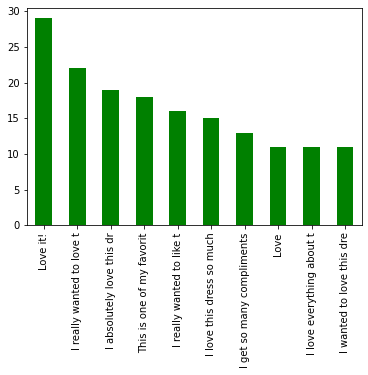

In [103]:
df['review_summary'].value_counts().nlargest(10).plot(kind='bar',color='green')
plt.show()

There are no negative reviews in the review_summary column

 7. Find out the average shoe size for the different fits of the customer. Visualize using any relevant plot. Explain that, Is there any significant different shoe sizes for different fits?

In [105]:
df.head(3)

,item_id,size,quality,cup size,hips,bra size,category,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
6725,152702,4,4.0,b,37.0,32.0,new,5ft 6in,avNYC,just right,small,668176,9.0,average,Too much ruching,"I liked the color, the silhouette, and the fab..."
6747,152702,12,5.0,c,35.0,36.0,new,5ft 4in,vpadilla413,just right,small,744129,8.0,average,I love this dress! The c,I love this dress! The color and style is per...
6748,152702,8,5.0,dd/e,38.0,32.0,new,5ft 1in,marissasco,slightly long,fit,889009,5.0,average,This dress is fantastic!,This dress is fantastic! I was hesitant to buy...


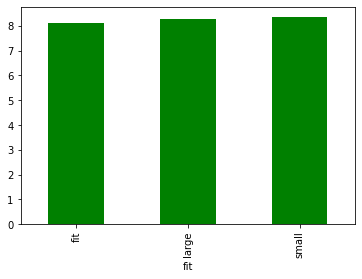

In [106]:
df.groupby('fit').mean()['shoe size'].plot(kind='bar',color = 'green')
plt.show()

Therefore there is no significance in different shoe size for different fits.

8 . Identify the customer’s common shoe width and average size for those who purchased the maximum quality. Is the mode of shoe width affect the user review? Visualize using the appropriate plot.

In [107]:
df.head(2)

,item_id,size,quality,cup size,hips,bra size,category,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
6725,152702,4,4.0,b,37.0,32.0,new,5ft 6in,avNYC,just right,small,668176,9.0,average,Too much ruching,"I liked the color, the silhouette, and the fab..."
6747,152702,12,5.0,c,35.0,36.0,new,5ft 4in,vpadilla413,just right,small,744129,8.0,average,I love this dress! The c,I love this dress! The color and style is per...


In [108]:
df['quality'].unique()

array([4., 5., 2., 3., 1.])

In [110]:
df['shoe width'].value_counts() #### Common shoe width is average


average    11798
wide        3496
narrow      1396
Name: shoe width, dtype: int64

In [111]:
print ('Average size for those who purchased the maximum quality :', df[df['quality']==5.0].mean()['size'])

Average size for those who purchased the maximum quality : 11.890309343434344


 9. Extract the records belonging to the top 10 reviews, and then find the review summary for the different cup sizes. The basic analysis explains what you would try to infer. Try to use visualization.

In [115]:
df['review_summary'].value_counts().nlargest(10)

Love it!                     29
I really wanted to love t    22
I absolutely love this dr    19
This is one of my favorit    18
I really wanted to like t    16
I love this dress so much    15
I get so many compliments    13
Love                         11
I love everything about t    11
I wanted to love this dre    11
Name: review_summary, dtype: int64

In [116]:
df.groupby('cup size').max()['review_summary']

cup size
a              was a little tight in the
aa             very lovely dress! i have
b              what a darling dress! lov
c         weird tail if you have a booty
d              yup. This coat is amazing
dd/e           worth the investment!  fi
ddd/f                               yup.
dddd/g          what a gorgeous coat  it
h              very cute skirt. I didn't
i              With all the love I've se
j              Very nice cropped cardiga
k              Yes, order a size up when
Name: review_summary, dtype: object

<AxesSubplot:>

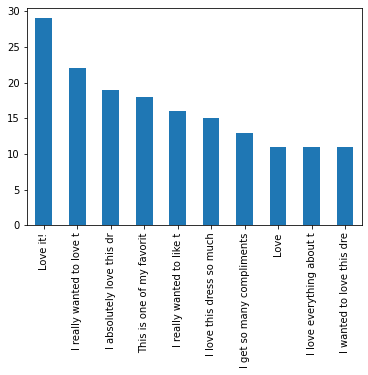

In [120]:
df['review_summary'].value_counts().head(10).plot(kind='bar')

 10. Identify the most common review that we got from the customer whose hips size is greater than 35. Find out what kind of inference you can make.

In [121]:
c = df[df['hips']>35]
c['review_summary'].value_counts().nlargest(1)

Love it!    25
Name: review_summary, dtype: int64

The inference we can make is that even the customer whose hip size is greater than 35 are fully satisfied with the product

 11. What is the relationship between height and weight? Describe what kind of relationship it has.

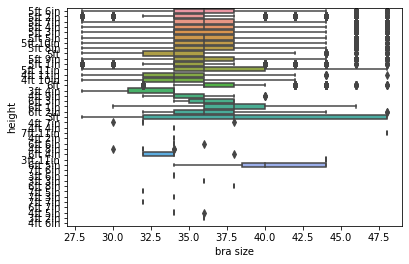

In [30]:
sns.boxplot(df['bra size'],df['height'])
plt.show()

12 . Plot the pair plot for the numerical plot. Explain according to your problem statement how the pair plot would help you.\

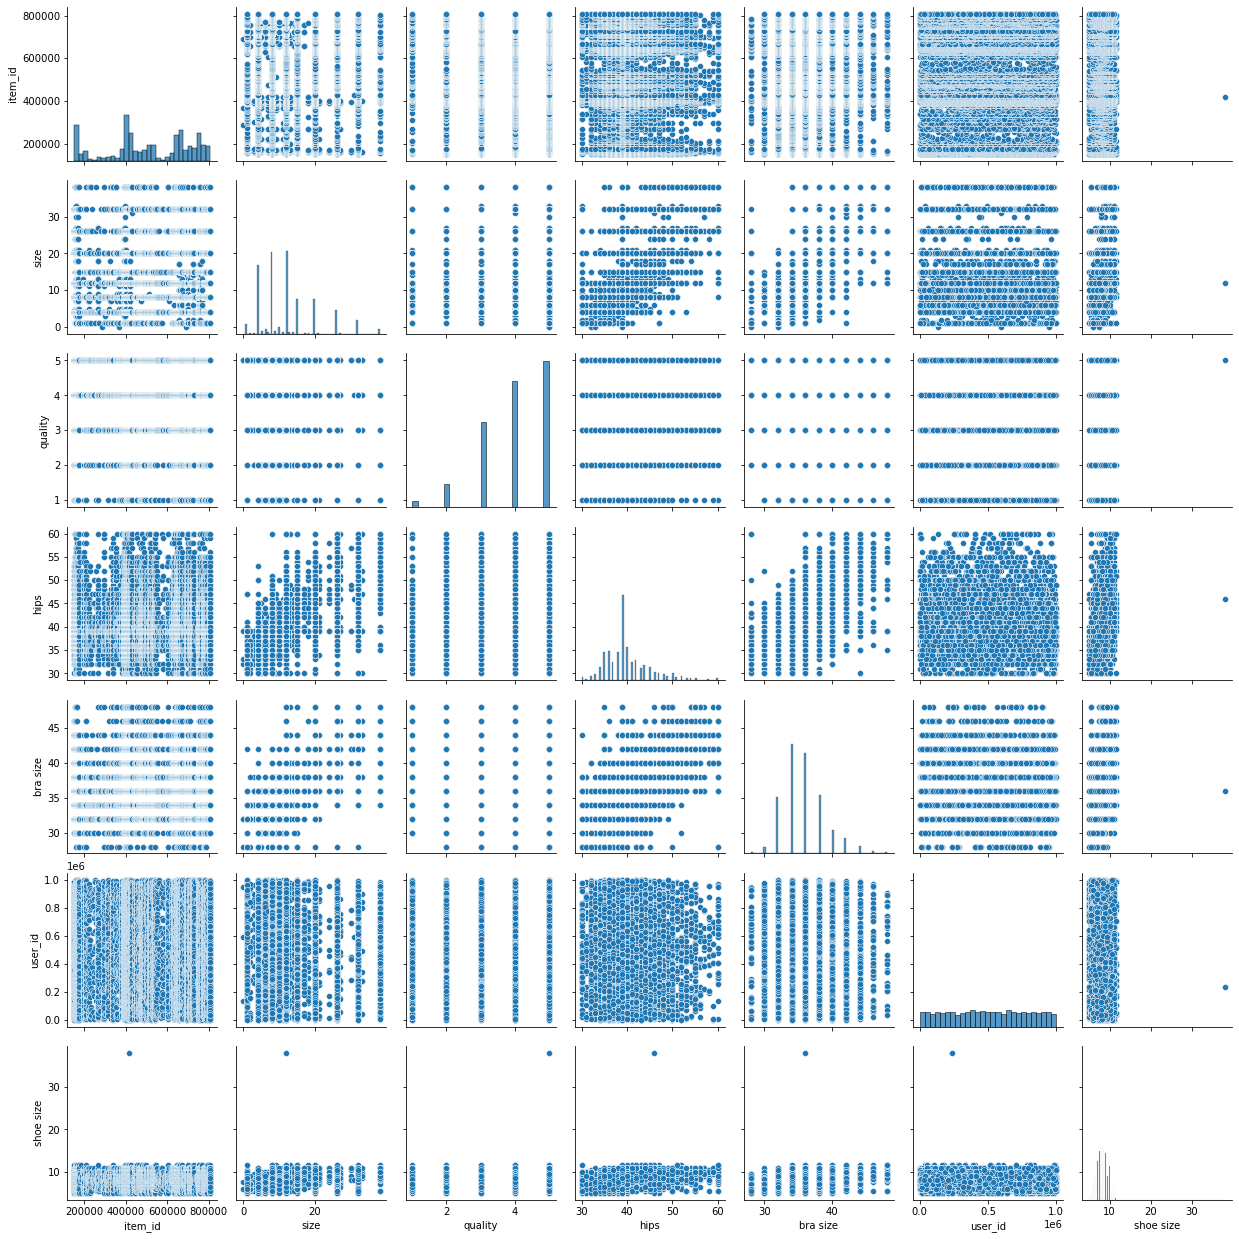

In [132]:
sns.pairplot(df)
plt.show()

# Statistical Anaylysis :

1 .Test the claim that the category feature and review summary have any relationship among them. The level of significance is 5%.

In [ ]:
H0=There is no relationship between review summary and category
H1=There is no relation between review summary and category

In [34]:
df.head()

,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,5ft 6in,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,5ft 7in,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN
3,123373,NaN,21,5.0,dd/e,NaN,NaN,new,NaN,NaN,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,NaN
4,123373,NaN,18,5.0,b,NaN,36.0,new,NaN,5ft 2in,dberrones1,slightly long,small,944840,NaN,NaN,NaN,NaN


In [33]:
stats.chi2_contingency(pd.crosstab(df['category'],df['review_summary']))

(391078.0863516312,
 6.985842997042375e-125,
 370272,
 array([[0.40139354, 0.20069677, 0.20069677, ..., 0.20069677, 0.20069677,
         0.20069677],
        [0.49031749, 0.24515875, 0.24515875, ..., 0.24515875, 0.24515875,
         0.24515875],
        [0.3882206 , 0.1941103 , 0.1941103 , ..., 0.1941103 , 0.1941103 ,
         0.1941103 ],
        ...,
        [0.06636429, 0.03318215, 0.03318215, ..., 0.03318215, 0.03318215,
         0.03318215],
        [0.5354368 , 0.2677184 , 0.2677184 , ..., 0.2677184 , 0.2677184 ,
         0.2677184 ],
        [0.00723066, 0.00361533, 0.00361533, ..., 0.00361533, 0.00361533,
         0.00361533]]))

Since p_value is <0.05 so we reject null hypothesis.Therefore,there is relation between review and summary category 

In [ ]:
H0=There is a relationship between quality and bra size
H1= There is a relationship between quality and bra size

In [39]:
stats.chi2_contingency(pd.crosstab(df['quality'],df['bra size']))

(139.7153793379851,
 5.636402968240407e-13,
 40,
 array([[4.07994995e+00, 1.66849315e+01, 1.59006921e+02, 3.55622408e+02,
         3.11346220e+02, 1.89217601e+02, 8.11227402e+01, 5.35156081e+01,
         3.19410868e+01, 9.44579852e+00, 6.01673553e+00],
        [1.58608892e+01, 6.48630137e+01, 6.18142669e+02, 1.38248941e+03,
         1.21036482e+03, 7.35587308e+02, 3.15366318e+02, 2.08043025e+02,
         1.24171630e+02, 3.67207356e+01, 2.33901829e+01],
        [6.07302895e+01, 2.48356164e+02, 2.36682716e+03, 5.29345998e+03,
         4.63440637e+03, 2.81651487e+03, 1.20751665e+03, 7.96582902e+02,
         4.75444912e+02, 1.40601254e+02, 8.95594541e+01],
        [8.45266478e+01, 3.45671233e+02, 3.29423698e+03, 7.36763205e+03,
         6.45033703e+03, 3.92012885e+03, 1.68066603e+03, 1.10871335e+03,
         6.61741694e+02, 1.95693990e+02, 1.24652138e+02],
        [9.18022236e+01, 3.75424658e+02, 3.57778627e+03, 8.00179615e+03,
         7.00554556e+03, 4.25755137e+03, 1.82532826e+03, 1.204

Since p_value so we reject null hypothesis .Therefore there is no relation between quality and bra size

2. Test statistically whether the size and hips have any relationship using 0.05 alpha. Before the above test, Test the normality test.

In [42]:
df.head(2)

,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,5ft 6in,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN


In [43]:
# for the normality test we use the wilks shapiro test
stat, p_value = stats.shapiro(df['hips'])
print('p_value',p_value)

p_value 1.0


Sice the p_value is less than 0.05 we reject hO conclude that the hip data is not normal.

h0=size and hips are not realted to each other
h1=size and hips are relaated toe each other

In [46]:
df['hips'].unique()

array([38., 30., nan, 41., 42., 50., 49., 60., 36., 44., 39., 35., 34.,
       32., 48., 52., 40., 46., 37., 45., 55., 51., 33., 53., 54., 47.,
       59., 43., 57., 58., 31., 56.])

In [47]:
df['size'].unique()

array([ 7, 13, 21, 18, 11,  5, 30, 24, 33,  3, 27, 15,  9, 12, 26, 20,  4,
        8, 32, 38,  1,  0,  6, 31, 10, 14, 17,  2, 25], dtype=int64)

In [52]:
# Coreelation
df['hips'].corr(df['size'])

0.7472568945998311

In [56]:
stats.ttest_ind (df['hips'],df['size'])

Ttest_indResult(statistic=nan, pvalue=nan)

Since p value is Less than 0.05 we reject HO. Therefore size and hips are related to each other

3 . Does the quality significantly differ for any one shoe width? Test the test with 96% confidence intervals.Check the normality of the data before the above test. Alpha = 0.4

In [59]:
# Normality test
stats.shapiro(df['quality'])
# The data is not normal

ShapiroResult(statistic=nan, pvalue=1.0)

In [ ]:
H0:Quality does not significantly differ for anyone shoe width
H1:Quality does not significantly differ for anyone shoe width

In [60]:
pd.crosstab(df['quality'],df['shoe width'])

shoe width,average,narrow,wide
quality,,,
1.0,181,26,71
2.0,771,89,241
3.0,2842,347,944
4.0,4317,480,1266
5.0,4973,607,1433


In [62]:
stats.chi2_contingency(pd.crosstab(df['quality'],df['shoe width']))

(16.206782667932107,
 0.039514250921588875,
 8,
 array([[ 195.68280611,   23.16666667,   59.15052722],
        [ 774.9883796 ,   91.75      ,  234.2616204 ],
        [2909.19797719,  344.41666667,  879.38535614],
        [4267.71530019,  505.25      , 1290.03469981],
        [4936.41553691,  584.41666667, 1492.16779643]]))

Since the pvalue is greater than 0.04, we fail to reject null hypothesis.Therefore quality does not significantly differ for any one shoe width

4. Check if the shoe width feature affects the review summary with a 99% confidence interval.

In [ ]:
H0:Shoe width feature does not affect the review summary
H1:Shoe width feature affect the review summary.

In [63]:
pd.crosstab(df['shoe width'],df['review_summary'])

review_summary,#FashionDeux I have been,#FashionDeux This skirt i,#Review ContestAlthough t,#ReviewContest I don't,#ReviewContest I wish,#ReviewContest Love th,#ReviewContest Super c,#ReviewContest Can't st,#ReviewContest I love t,#ReviewContest I wasn't,...,what a gorgeous coat it,wish I had sized down. fe,wish it was a tad longer,with all the reviews and,wore larger than last sea,worth the investment! fi,you could probably size d,you know who this dress d,yup.,yup. This coat is amazing
shoe width,,,,,,,,,,,,,,,,,,,,,
average,1,1,1,1,1,4,1,1,1,1,...,1,1,1,1,1,0,0,1,1,1
narrow,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
wide,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [64]:
stats.chi2_contingency(pd.crosstab(df['shoe width'],df['review_summary']))

(31796.729375119932,
 0.0004914097065158217,
 30970,
 array([[0.70447451, 0.70447451, 0.70447451, ..., 0.70447451, 0.70447451,
         0.70447451],
        [0.08365129, 0.08365129, 0.08365129, ..., 0.08365129, 0.08365129,
         0.08365129],
        [0.21187421, 0.21187421, 0.21187421, ..., 0.21187421, 0.21187421,
         0.21187421]]))

Since the pvalue is less than 0.01 we reject the null Hypothesis therefore we conclude that shoe width feature does affect the review summary

In [65]:
stats.chi2_contingency(pd.crosstab(df['review_summary'],df['bra size']))

(590585.3911283453,
 2.076030570523768e-49,
 574650,
 array([[0.00658726, 0.02771192, 0.26266699, ..., 0.05195985, 0.01547438,
         0.0098525 ],
        [0.00329363, 0.01385596, 0.13133349, ..., 0.02597993, 0.00773719,
         0.00492625],
        [0.00329363, 0.01385596, 0.13133349, ..., 0.02597993, 0.00773719,
         0.00492625],
        ...,
        [0.00329363, 0.01385596, 0.13133349, ..., 0.02597993, 0.00773719,
         0.00492625],
        [0.00329363, 0.01385596, 0.13133349, ..., 0.02597993, 0.00773719,
         0.00492625],
        [0.00329363, 0.01385596, 0.13133349, ..., 0.02597993, 0.00773719,
         0.00492625]]))

Since the pvalue is less than 0.01 we reject the null Hypothesis therefore we cinclude that review_summary does affect the bra size

5 . Check if the length feature affects the review summary with a 95% confidence interval.

In [ ]:
H0 : Length feature does not affect the review summary.
H1 : Length feature does affect the review summary.

In [69]:
pd.crosstab(df['length'],df['review_summary'])

review_summary,!,!!!,!!!!,#4 for me! I'm collecting,#FashionDeux Absolutely,#FashionDeux This is the,#FashionDeux I have been,#FashionDeux This skirt i,#Review ContestAlthough t,#ReviewContest,...,you have it in other colo,you know who this dress d,you may see similar cardi,you need every color,you should buy every colo,you shouldn't have to spe,yup.,yup. This coat is amazing,"zipper stuck a little, bu",zipper very difficult to
length,,,,,,,,,,,,,,,,,,,,,
just right,1,1,1,1,1,0,1,1,0,1,...,1,1,1,1,1,1,1,1,1,1
slightly long,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
slightly short,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
very long,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
very short,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [70]:
stats.chi2_contingency(pd.crosstab(df['length'],df['review_summary']))

(262566.9171487105,
 4.2550774426859785e-108,
 246748,
 array([[1.48871528, 0.74435764, 0.74435764, ..., 0.74435764, 0.74435764,
         0.74435764],
        [0.2812237 , 0.14061185, 0.14061185, ..., 0.14061185, 0.14061185,
         0.14061185],
        [0.14977904, 0.07488952, 0.07488952, ..., 0.07488952, 0.07488952,
         0.07488952],
        [0.06110585, 0.03055293, 0.03055293, ..., 0.03055293, 0.03055293,
         0.03055293],
        [0.01917614, 0.00958807, 0.00958807, ..., 0.00958807, 0.00958807,
         0.00958807]]))

Since the pvalue is less than 0.05 we reject the Null Hypothesis therefore we conclude the length fetaure does affect the review summary. 

6 . Does the average quality significantly differ for the different fits? Kindly test the relevant hypothesis test by having 0.05 alpha. Check the normality of the data before the above test. Alpha = .05

In [71]:
# Normality test
stats.shapiro(df['quality'])
# The data is not normal

ShapiroResult(statistic=nan, pvalue=1.0)

In [ ]:
H0 :Average quality does not significantly differ for the different fits
H1: Average quality significantly differ for the different fits

In [80]:
df['fit'].unique()

array(['small', 'fit', 'large'], dtype=object)

In [84]:
small=df[df['fit']=='small']['quality']
fit=df[df['fit']=='fit']['quality']
large=df[df['fit']=='large']['quality']



In [85]:
stats.f_oneway(small,fit,large)

F_onewayResult(statistic=nan, pvalue=nan)

Since the pvalue is less than 0.05 we reject Ho. Therefore we can conclude that average quality significantly differ for the different fits.

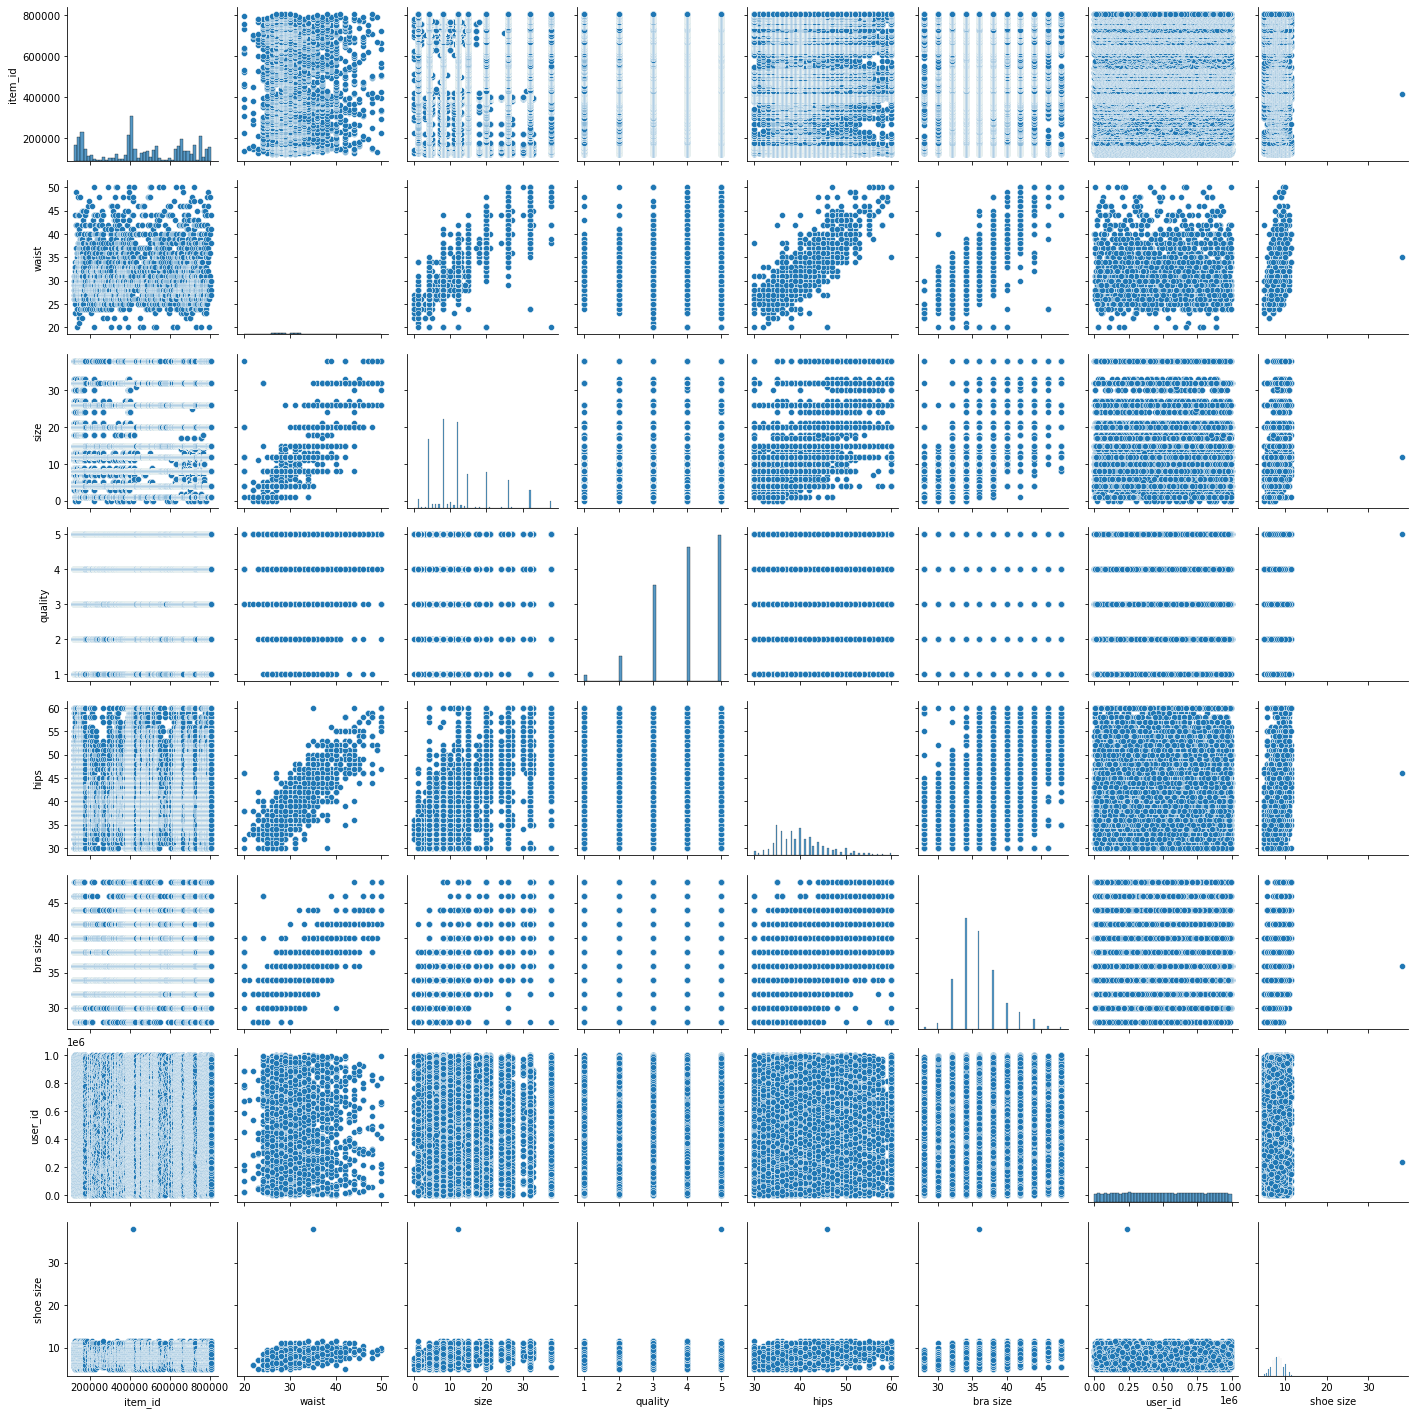

In [92]:
sns.pairplot(df)
plt.show()